## **PROMOTE Sprint - Day 1**
### Tutorial 2. Analysing UKESM1-2-LL with NEMO Cookbook

##### 13th July 2026

#### **Contact:**
Ollie Tooth (oliver.tooth@noc.ac.uk)

#### **Background:**
---

In this second hands-on tutorial, we will use the `NEMODataTree` object to analyse ocean & sea-ice outputs of the UKESM1-2-LL TIPMIP idealised emissions scenarios.

We will cover:

* Opening virtual `NEMODataTree` objects directly from Icechunk repositories using the `from_icechunk()` constructor.

* Exploring NEMO ocean & sea-ice variables stored in a `NEMODataTree`.

* Calculating March mixed layer volume for the subpolar North Atlantic using `NEMODataArray.integral()`.

#### **2.1 Creating NEMODataTrees**
---

* Let's begin by importing the **NEMO Cookbook** Python library and the `NEMODataTree` class:

In [1]:
import os

import cartopy.crs as ccrs
import icechunk
import matplotlib.pyplot as plt
from xarray.coders import CFDatetimeCoder
from nemo_cookbook import NEMODataTree

##### **2.1.1 Virtual NEMODataTrees**

* Rather that having to merge *O*(100) - *O*(1000s) of netCDF files to create a `NEMODataTree` at the begining of every script, we can alternatively build a virtual `NEMODataTree`:

`Virtual NEMODataTree` -> lightweight, persistent map describing how to organise our netCDF files into a `NEMODataTree`.

* For the PROMOTE Analysis Sprint, we have created virtual `NEMODataTrees` for the following simulations:

    * **UKESM1-2-LL**: `/gws/ssde/j25b/terrafirma/otooth/repos/`

    * **CANARI-LE**: `/gws/ssde/j25b/canari/shared/large-ensemble/ocean/repos/`

* To access virtual `NEMODataTrees`, we can use the `.from_icechunk()` constructor:

---

`from_icechunk()`

* Creates a `NEMODataTree` from an Icechunk repository:

```
    <xarray.DataTree 'nemo'>
    Group: /
    ├── Group: /gridT
    ├── Group: /gridU
    ├── Group: /gridV
    ├── Group: /gridW
    └── Group: /gridF
```

where each grid node is stored as a virtual dataset in separate groups of a hierarchical Icechunk store.

---

* Here, we show how to construct a `NEMODataTree` from the 1° global ocean sea-ice component of **UKESM1-2-LL** using the available Icechunk repositories accessible via the `terrafirma` group workspace.

* Let's start by exploring the available Icechunk repositories...

In [2]:
os.listdir("/gws/ssde/j25b/terrafirma/otooth/repos/")

['UKESM1-2-LL_esm-hist_r1i1p1f1',
 'UKESM1-2-LL_esm-hist_r2i1p1f1',
 'UKESM1-2-LL_esm-hist_r3i1p1f1',
 'UKESM1-2-LL_esm-piControl_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl2p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl3p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl4p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl5p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl2p0-50y-dn1p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl2p0-50y-dn2p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl3p0-50y-dn2p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl4p0-50y-dn1p0_r1i1p1f1',
 'UKESM1-2-LL_esm-up2p0-gwl4p0-50y-dn2p0_r1i1p1f1']

* Next, let's define a reusable function `open_virtual_NEMODataTree()` to open a virtual `NEMODataTree` given the `experiment` and `member` of a UKESM1-2-LL simulation...

In [3]:
def open_virtual_NEMODataTree(
        experiment: str,
        member: str = "r1i1p1f1"
    ) -> NEMODataTree:

    # Authorise Icechunk to fetch virtual chunks from the original netCDF files on JASMIN terrafirma group workspace:
    store_fpath = "/gws/ssde/j25b/terrafirma"
    credentials = icechunk.credentials.containers_credentials({f"file://{store_fpath}/": icechunk.credentials.LocalFileSystemAccess})

    # Open Icechunk repository stored on JASMIN terrafirma group workspace:
    repo_fpath = f"/gws/ssde/j25b/terrafirma/otooth/repos/UKESM1-2-LL_{experiment}_{member}"
    repo = icechunk.Repository.open(storage=icechunk.local_filesystem_storage(repo_fpath),
                                    authorize_virtual_chunk_access=credentials
                                    )
    
    # Create virtual NEMODataTree from Icechunk repository:
    nemo = NEMODataTree.from_icechunk(repo=repo,
                                      branch="main",
                                      iperio=True,
                                      nftype="F",
                                      name=f"UKESM1-2-LL_{experiment}_{member}",
                                      open_kwargs={"decode_times": CFDatetimeCoder(time_unit="s"),
                                                   "chunks": {},
                                                   }
                                      )

    return nemo

In [4]:
# Open virtual NEMODataTree from UKESM1-2-LL esm-up2p0 Icechunk repository:
nemo = open_virtual_NEMODataTree(experiment="esm-up2p0", member="r1i1p1f1")

nemo

  2026-07-12T12:31:13.889491Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



<xarray.DataTree 'UKESM1-2-LL_esm-up2p0_r1i1p1f1'>
Group: /
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridF
│       Dimensions:       (j: 330, i: 360, k: 75, time_counter: 3480)
│       Coordinates:
│         * j             (j) float64 3kB 1.5 2.5 3.5 4.5 ... 327.5 328.5 329.5 330.5
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│           gphif         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           glamf         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│         * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
│       Data variables:
│           e1f           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           fmaskutil     (j, i) int8 119kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           fmask         (k, j, i) int8 9MB dask.array<chunksize=(75, 330, 360), meta=np.ndarray>
│           e2f           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridU
│       Dimensions:       (j: 330, i: 360, time_counter: 3480, k: 75, bnds: 2)
│       Coordinates:
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│           gphiu         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
│           glamu         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
│         * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│           depthu        (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
│       Dimensions without coordinates: bnds
│       Data variables:
│           e1u           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           e2u           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           lev_bnds      (time_counter, k, bnds) float64 4MB dask.array<chunksize=(1, 75, 2), meta=np.ndarray>
│           tauuo         (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
│           umo           (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
│           umaskutil     (j, i) int8 119kB dask.array<chunksize=(330, 360), meta=np.ndarray>
│           uo            (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
│           umask         (k, j, i) int8 9MB dask.array<chunksize=(75, 330, 360), meta=np.ndarray>
│       Attributes: (12/37)
│           Conventions:           CF-1.7 CMIP-6.2
│           activity_id:           TerraFIRMA
│           branch_method:         no parent
│           cv_version:            GCModelDev v0.0.17
│           data_specs_version:    GCModelDev v0.0.17
│           experiment:            unknown
│           ...                    ...
│           variable_name:         tauuo
│           variant_label:         r1i1p1f1
│           license:               GCModelDev model data is licensed under the Open G...
│           cmor_version:          3.7.3
│           nftype:                F
│           iperio:                True
├── Group: /gridV
│       Dimensions:       (j: 330, i: 360, time_counter: 3480, k: 75, bnds: 2)
│       Coordinates:
│         * j             (j) float64 3kB 1.5 2.5 3.5 4.5 ... 327.5 328.5 329.5 330.5
│         * i             

#### **2.2 Navigating a NEMODataTree**
---

* Now we have created an example `NEMODataTree`, let's take a closer look at its contents and how to access NEMO model output variables.

* We'll start by looking at the nodes in our `NEMODataTree`:

In [5]:
nemo.groups

('/', '/gridF', '/gridU', '/gridV', '/gridT', '/gridW')

**Some Important Points:**

* A `NEMODataTree` does not have a `domain` node since grid scale factors and masks associated with each model domain are assigned to their respective grid nodes during pre-processing (e.g., horizontal grid scale factors `e1t` and `e2t` are stored in `gridT` etc.).

* During the construction of a `NEMODataTree`, the standard (`depth{p}`, `y`, `x`) dimensions of NEMO model outputs (where `p` is the grid point type) are transformed to NEMO grid indices (**i**, **j**, **k**). This has two important implications:

    * `xarray.Datasets` stored in each grid node share the same coordinate dimension names (`i`, `j`, `k`), but are staggered according to the location of variables on the NEMO model grid.

    * All grid indices use Fortran (1-based) indexing to be consistent with the original NEMO model code.

    | Grid Type    | Grid Indices                 |
    | -----------  | --------------------------   |
    | `T`          | $(i, j, k)$                    |
    | `U`          | $(i + \frac{1}{2}, j, k)$              |
    | `V`          | $(i, j + \frac{1}{2}, k)$              |
    | `W`          | $(i, j, k + \frac{1}{2})$              |
    | `F`          | $(i + \frac{1}{2}, j + \frac{1}{2}, k)$        |

---

* To see what this means in practice, we will consider the `gridT` and `gridU` nodes of the 2° `AGRIF_DEMO` `NEMODataTree` below:

In [6]:
nemo['gridT']

<xarray.DataTree 'gridT'>
Group: /gridT
    Dimensions:       (j: 330, i: 360, time_counter: 3480, k: 75, bnds: 2)
    Coordinates:
      * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
      * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
        glamt         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        gphit         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
        longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
      * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
      * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
        deptht        (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
    Dimensions without coordinates: bnds
    Data variables: (12/26)
        e2t           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        e1t           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        chl           (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
        hfds          (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
        e3t           (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
        lev_bnds      (time_counter, k, bnds) float64 4MB dask.array<chunksize=(1, 75, 2), meta=np.ndarray>
        ...            ...
        sos           (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
        sithick       (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
        talk          (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
        tos           (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
        po4           (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
        zos           (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
    Attributes: (12/38)
        Conventions:           CF-1.7 CMIP-6.2
        activity_id:           TerraFIRMA
        branch_method:         no parent
        cv_version:            GCModelDev v0.0.17
        data_specs_version:    GCModelDev v0.0.17
        experiment:            unknown
        ...                    ...
        variable_name:         tos
        variant_label:         r1i1p1f1
        license:               GCModelDev model data is licensed under the Open G...
        cmor_version:          3.7.3
        nftype:                F
        iperio:                True

In [7]:
nemo['gridU']

<xarray.DataTree 'gridU'>
Group: /gridU
    Dimensions:       (j: 330, i: 360, time_counter: 3480, k: 75, bnds: 2)
    Coordinates:
      * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
      * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
        gphiu         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
        glamu         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
      * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
      * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
        depthu        (k) float64 600B dask.array<chunksize=(75,), meta=np.ndarray>
    Dimensions without coordinates: bnds
    Data variables:
        e1u           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        e2u           (j, i) float64 950kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        lev_bnds      (time_counter, k, bnds) float64 4MB dask.array<chunksize=(1, 75, 2), meta=np.ndarray>
        tauuo         (time_counter, j, i) float32 2GB dask.array<chunksize=(1, 330, 360), meta=np.ndarray>
        umo           (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
        umaskutil     (j, i) int8 119kB dask.array<chunksize=(330, 360), meta=np.ndarray>
        uo            (time_counter, k, j, i) float32 124GB dask.array<chunksize=(1, 38, 165, 180), meta=np.ndarray>
        umask         (k, j, i) int8 9MB dask.array<chunksize=(75, 330, 360), meta=np.ndarray>
    Attributes: (12/37)
        Conventions:           CF-1.7 CMIP-6.2
        activity_id:           TerraFIRMA
        branch_method:         no parent
        cv_version:            GCModelDev v0.0.17
        data_specs_version:    GCModelDev v0.0.17
        experiment:            unknown
        ...                    ...
        variable_name:         tauuo
        variant_label:         r1i1p1f1
        license:               GCModelDev model data is licensed under the Open G...
        cmor_version:          3.7.3
        nftype:                F
        iperio:                True

* Above, we have seen how to access the nodes in an `NEMODataTree` using a dictionary-like syntax.

* We can also extend this to include output variables stored in given grid node as follows...

* To access an **unmasked** variable (i.e., unchanged from the original model output files) as an `xarray.DataArray`:

In [8]:
nemo['gridT']['mlotst']

<xarray.DataArray 'mlotst' (time_counter: 3480, j: 330, i: 360)> Size: 2GB
dask.array<open_dataset-mlotst, shape=(3480, 330, 360), dtype=float32, chunksize=(1, 330, 360), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
  * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
  * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
    glamt         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    gphit         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
    longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
Attributes:
    standard_name:  ocean_mixed_layer_thickness_defined_by_sigma_t
    long_name:      Ocean Mixed Layer Thickness Defined by Sigma T
    comment:        Sigma T is potential density referenced to ocean surface.
    units:          m
    original_name:  mo: (variable_name: mlotst)
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello

* To access a **unmasked** variable as a `NEMODataArray` (i.e.,  NEMO grid-aware extension of `xarray.DataArray`), we can instead provide a direct path to the variable:

In [9]:
nemo["gridT/mlotst"]

<NEMODataTree 'UKESM1-2-LL_esm-up2p0_r1i1p1f1'>
  <NEMODataArray 'mlotst' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'mlotst' (time_counter: 3480, j: 330, i: 360)> Size: 2GB
dask.array<open_dataset-mlotst, shape=(3480, 330, 360), dtype=float32, chunksize=(1, 330, 360), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
  * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
  * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
    glamt         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    gphit         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
    longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
Attributes:
    standard_name:  ocean_mixed_layer_thickness_defined_by_sigma_t
    long_name:      Ocean Mixed Layer Thickness Defined by Sigma T
    comment:        Sigma T is potential density referenced to ocean surface.
    units:          m
    original_name:  mo: (variable_name: mlotst)
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello

* To access a **masked** (i.e., the appropriate land-sea mask is applied automatically) variable as an `NEMODataArray`, we can instead provide a direct path to the variable:

In [10]:
nemo["gridT/mlotst"].masked

<NEMODataTree 'UKESM1-2-LL_esm-up2p0_r1i1p1f1'>
  <NEMODataArray 'mlotst' (Domain: '.', Grid: 'gridT', Grid Type: 'T')>

<xarray.DataArray 'mlotst' (time_counter: 3480, j: 330, i: 360)> Size: 2GB
dask.array<where, shape=(3480, 330, 360), dtype=float32, chunksize=(1, 330, 360), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) object 28kB 1850-01-16 00:00:00 ... 2139-12-...
  * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 324 325 326 327 328 329 330
  * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
    glamt         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    gphit         (j, i) float32 475kB dask.array<chunksize=(330, 360), meta=np.ndarray>
    latitude      (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
    longitude     (j, i) float64 950kB dask.array<chunksize=(165, 180), meta=np.ndarray>
Attributes:
    standard_name:  ocean_mixed_layer_thickness_defined_by_sigma_t
    long_name:      Ocean Mixed Layer Thickness Defined by Sigma T
    comment:        Sigma T is potential density referenced to ocean surface.
    units:          m
    original_name:  mo: (variable_name: mlotst)
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello

#### **2.3 Plotting Data for the Subpolar North Atlantic**

---

* Since `NEMODataArray` is a wrapper around the familiar `xarray.DataArray`, we can still access `xarray.DataArray.plot` for exploratory plotting.

* However, for geographical plots of 2-dimensional `NEMODataArrays` with dimensions (`j`, `i`) only, we can use the `geoplot()` method to produce a Cartopy `GeoQuadMesh` as follows:

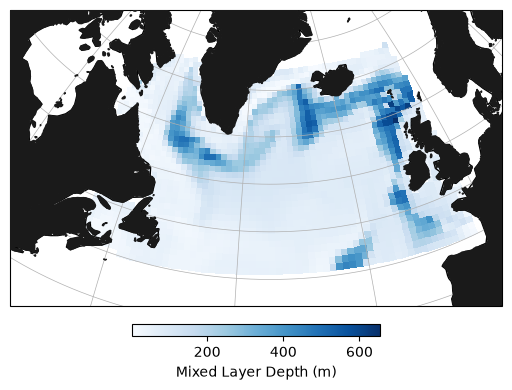

In [11]:
# Define subpolar North Atlantic boundary box for analysis:
bbox_spna = (-68, -2, 45, 67)  # (-68°E, -2°E, 45°N, 67°N)

# Plot the mixed layer depth (m) in the subpolar North Atlantic region:
(nemo["gridT/mlotst"]
 .clip(bbox_spna)
 .isel(time_counter=2)
 .geoplot(projection=ccrs.Orthographic(central_longitude=-35, central_latitude=50),
          extent=(-75, 0, 42, 70), # (-75°E, -0°E, 42°N, 70°N)
          cmap='Blues',
          clabel_kwargs={'label': 'Mixed Layer Depth (m)'}
          )
 )

#### **2.4 Calculating Subpolar North Atlantic March Mixed Layer Diagnostics**

---

* Next, let's calculate the March mixed layer volume for our subpolar North Atlantic regional subdomain using the `.integral()` method: 

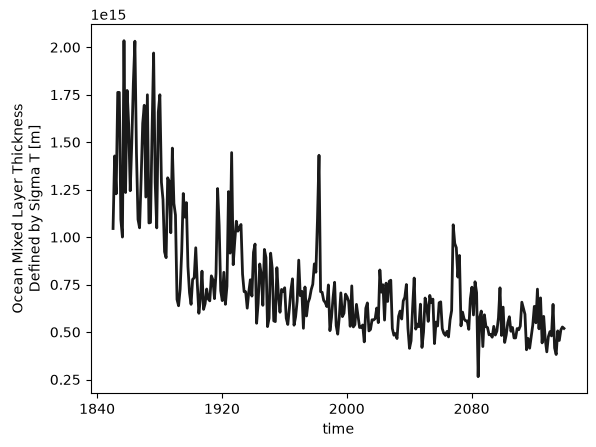

In [12]:
(nemo["gridT/mlotst"]
 .clip(bbox_spna)
 .sel(time_counter=nemo["gridT/time_counter"].dt.month == 3)
 .integral(dims=["i", "j"])
 .plot(linewidth=2, color='0.1')
 )

#### **2.5 Plotting Subpolar North Atlantic March Mixed Layer Changes**

---

* Let's next visualise the change in the March mixed layer volume over the course of the esm-up2p0 experiment for our subpolar North Atlantic regional subdomain using the `.clip()` and `.geoplot` methods: 

Text(0.5, 1.0, 'Change in Mixed Layer Depth (MLD)\nesm-up2p0 [2090-2139] - [1850-1900]')

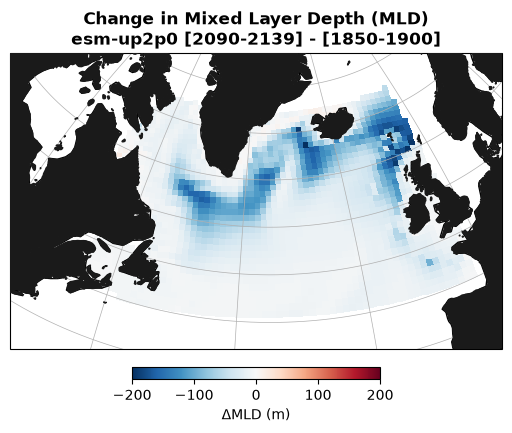

In [13]:
# Plot the sea surface temperature (°C) in the subpolar North Atlantic region:
mlotst_1850_1900 = nemo["gridT/mlotst"].sel(time_counter=slice("1850-01", "1900-12")).mean(dim="time_counter")
mlotst_2090_2139 = nemo["gridT/mlotst"].sel(time_counter=slice("2090-01", "2139-12")).mean(dim="time_counter")

((mlotst_2090_2139 - mlotst_1850_1900)
 .clip(bbox_spna)
 .geoplot(projection=ccrs.Orthographic(central_longitude=-35, central_latitude=50),
          extent=(-75, 0, 42, 70),
          vmin=-200, vmax=200,
          cmap='RdBu_r',
          clabel_kwargs={'label': '$\\Delta$MLD (m)'}
          )
 )

plt.title("Change in Mixed Layer Depth (MLD)\nesm-up2p0 [2090-2139] - [1850-1900]", fontweight='bold')